In [1]:
import numpy as np
import pandas as pd
import anndata
import os
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn import preprocessing
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap

import portal

In [2]:
data_path = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/oin_trajectory_integration_portal/preprocessed_data"
adata_heart = sc.read_h5ad(data_path + "/oin_heart.h5ad")
adata_gut = sc.read_h5ad(data_path + "/oin_gut.h5ad")
adata_lung = sc.read_h5ad(data_path + "/oin_lung.h5ad")
adata_pan = sc.read_h5ad(data_path + "/oin_pan.h5ad")

In [3]:
adata_heart = adata_heart[(adata_heart.obs.seurat_clusters.values.astype(str)!="5") & (adata_heart.obs.seurat_clusters.values.astype(str)!="8"), :]
adata_gut = adata_gut[(adata_gut.obs.seurat_clusters.values.astype(str)!="5") & (adata_gut.obs.seurat_clusters.values.astype(str)!="8"), :]
adata_lung = adata_lung[(adata_lung.obs.seurat_clusters.values.astype(str)!="5") & (adata_lung.obs.seurat_clusters.values.astype(str)!="8"), :]
adata_pan = adata_pan[(adata_pan.obs.seurat_clusters.values.astype(str)!="5") & (adata_pan.obs.seurat_clusters.values.astype(str)!="8"), :]

In [4]:
adata_heart.shape, adata_gut.shape, adata_lung.shape, adata_pan.shape

((2450, 32285), (4239, 32285), (1686, 32285), (2741, 32285))

In [5]:
# np.random.seed(seed=5678)
# n_cells = 1686

# idx = np.random.choice(adata_heart.shape[0], n_cells, replace=False)
# adata_heart = adata_heart[idx, :]

# idx = np.random.choice(adata_gut.shape[0], n_cells, replace=False)
# adata_gut = adata_gut[idx, :]

# idx = np.random.choice(adata_lung.shape[0], n_cells, replace=False)
# adata_lung = adata_lung[idx, :]

# idx = np.random.choice(adata_pan.shape[0], n_cells, replace=False)
# adata_pan = adata_pan[idx, :]

# adata_heart.shape, adata_gut.shape, adata_lung.shape, adata_pan.shape

In [6]:
adata_list = [adata_lung, adata_pan, adata_heart, adata_gut]
adata_full = adata_lung.concatenate(adata_pan, adata_heart, adata_gut)

/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [7]:
lowdim_list = portal.utils.preprocess_datasets(adata_list, hvg_num=2000)

Finding highly variable genes...


/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:149: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': 'seurat_v3'}
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:149: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': 'seurat_v3'}
/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/oin_trajectory_integration_portal/codes_integration/portal/utils.py:39: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead.
  hvg_total = hvg_total & hvg
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.p

Normalizing and scaling...


/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packag

Dimensionality reduction via PCA...


/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Mon Mar 25 20:18:46 2024 Construct fuzzy simplicial set
Mon Mar 25 20:18:46 2024 Finding Nearest Neighbors
Mon Mar 25 20:18:46 2024 Building RP forest with 10 trees
Mon Mar 25 20:18:48 2024 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon Mar 25 20:18:57 2024 Finished Nearest Neighbor Search
Mon Mar 25 20:18:59 2024 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Mar 25 20:19:10 2024 Finished embedding


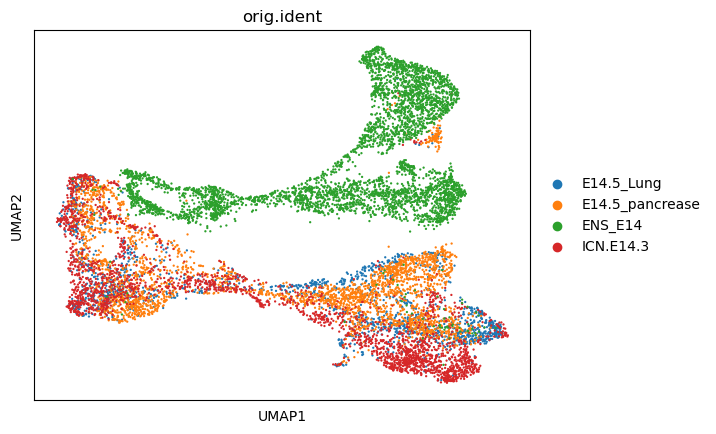

In [8]:
pcs_full = np.concatenate(lowdim_list, axis=0)
adata_full.obsm["pcs"] = pcs_full

import umap
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['pcs'])
adata_full.obsm["X_umap"] = embedding
sc.pl.umap(adata_full, color=["orig.ident"])

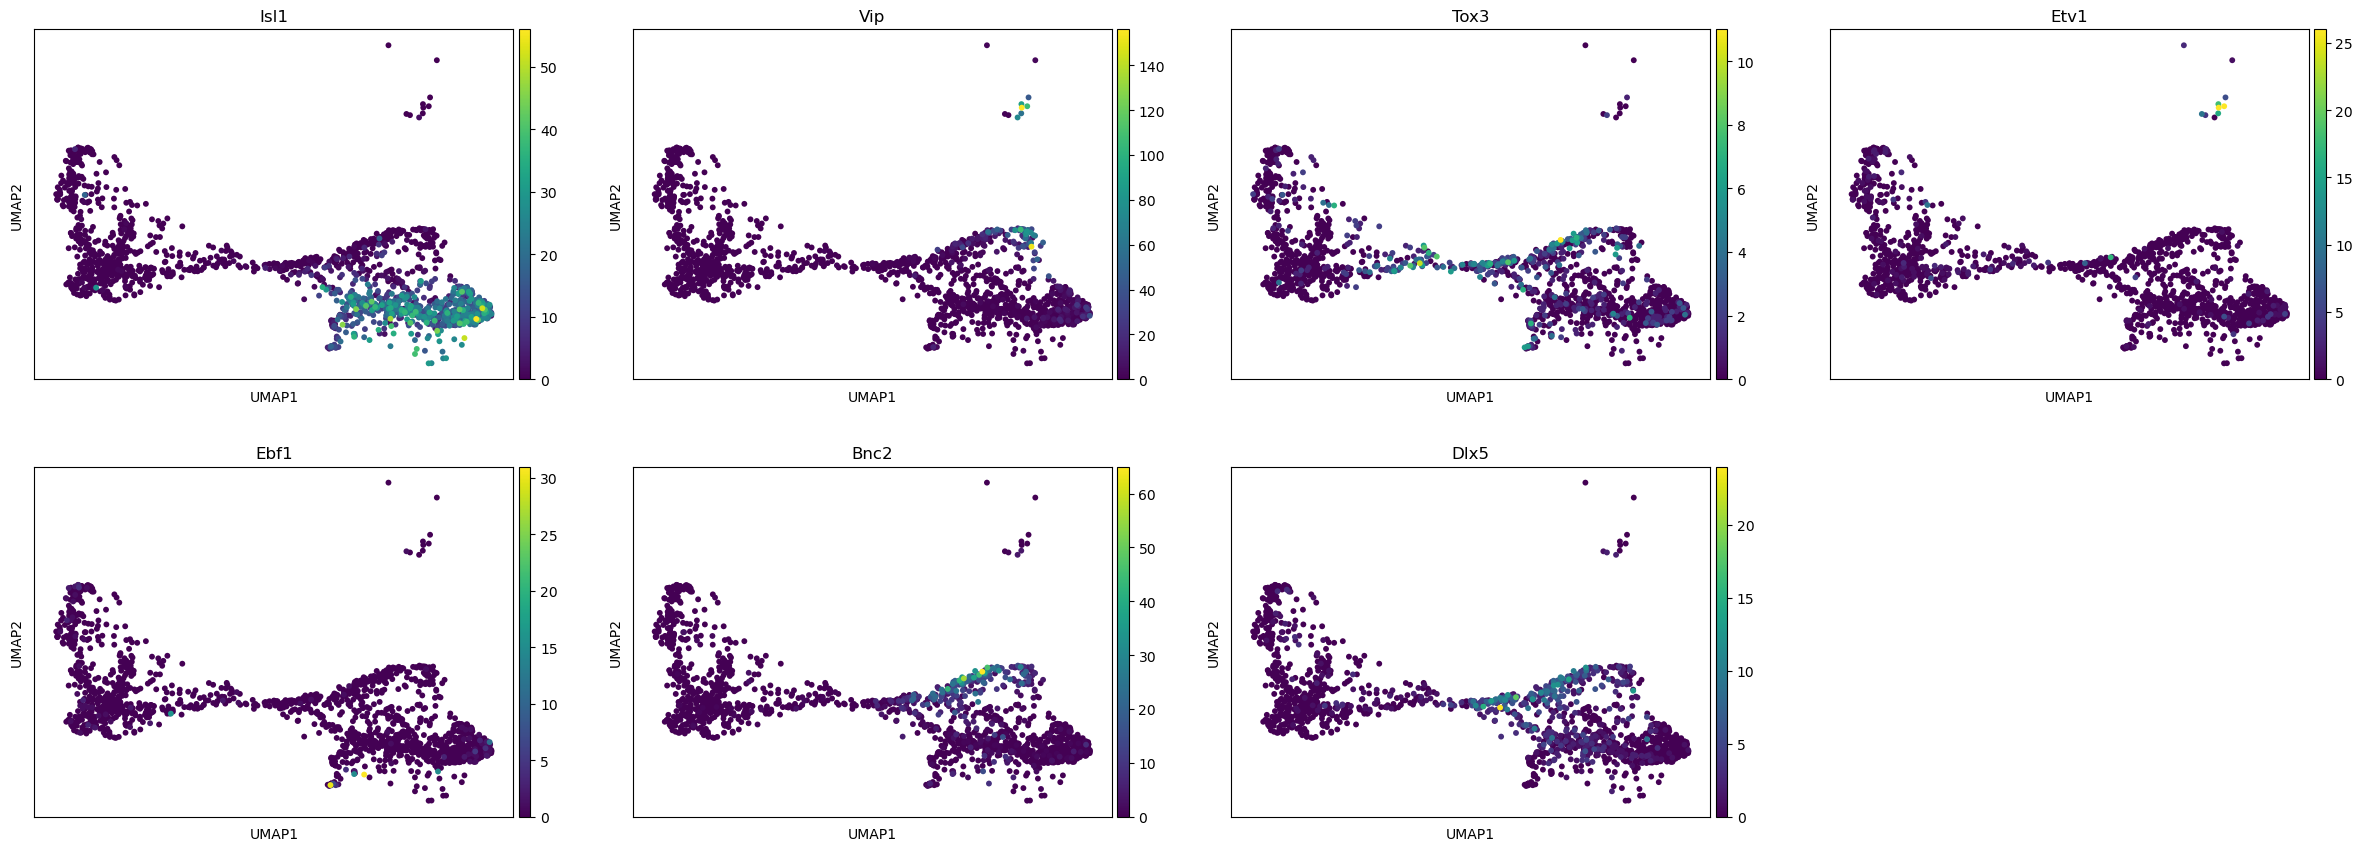

In [9]:
adata_plot_lung = adata_full[adata_full.obs["orig.ident"] == "E14.5_Lung", :]
sc.pl.umap(adata_plot_lung, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

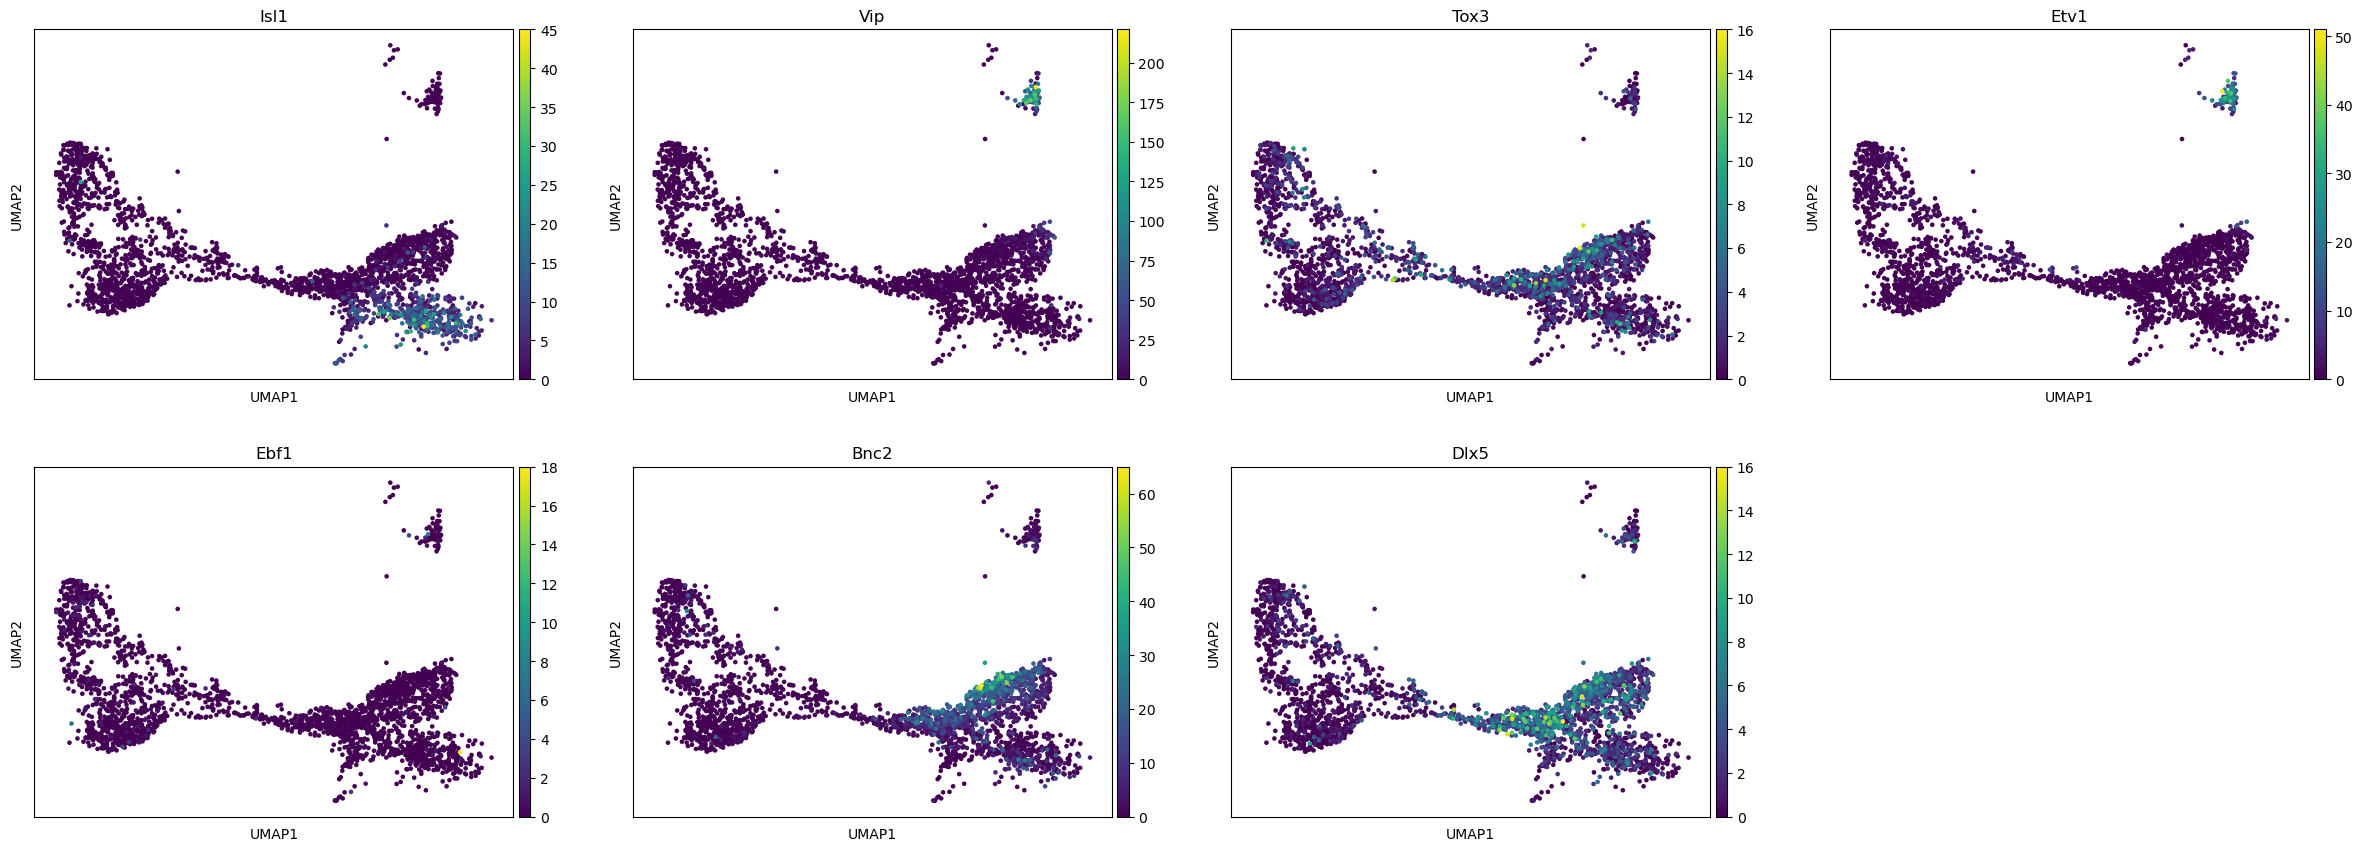

In [10]:
adata_plot_pan = adata_full[adata_full.obs["orig.ident"] == "E14.5_pancrease", :]
sc.pl.umap(adata_plot_pan, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

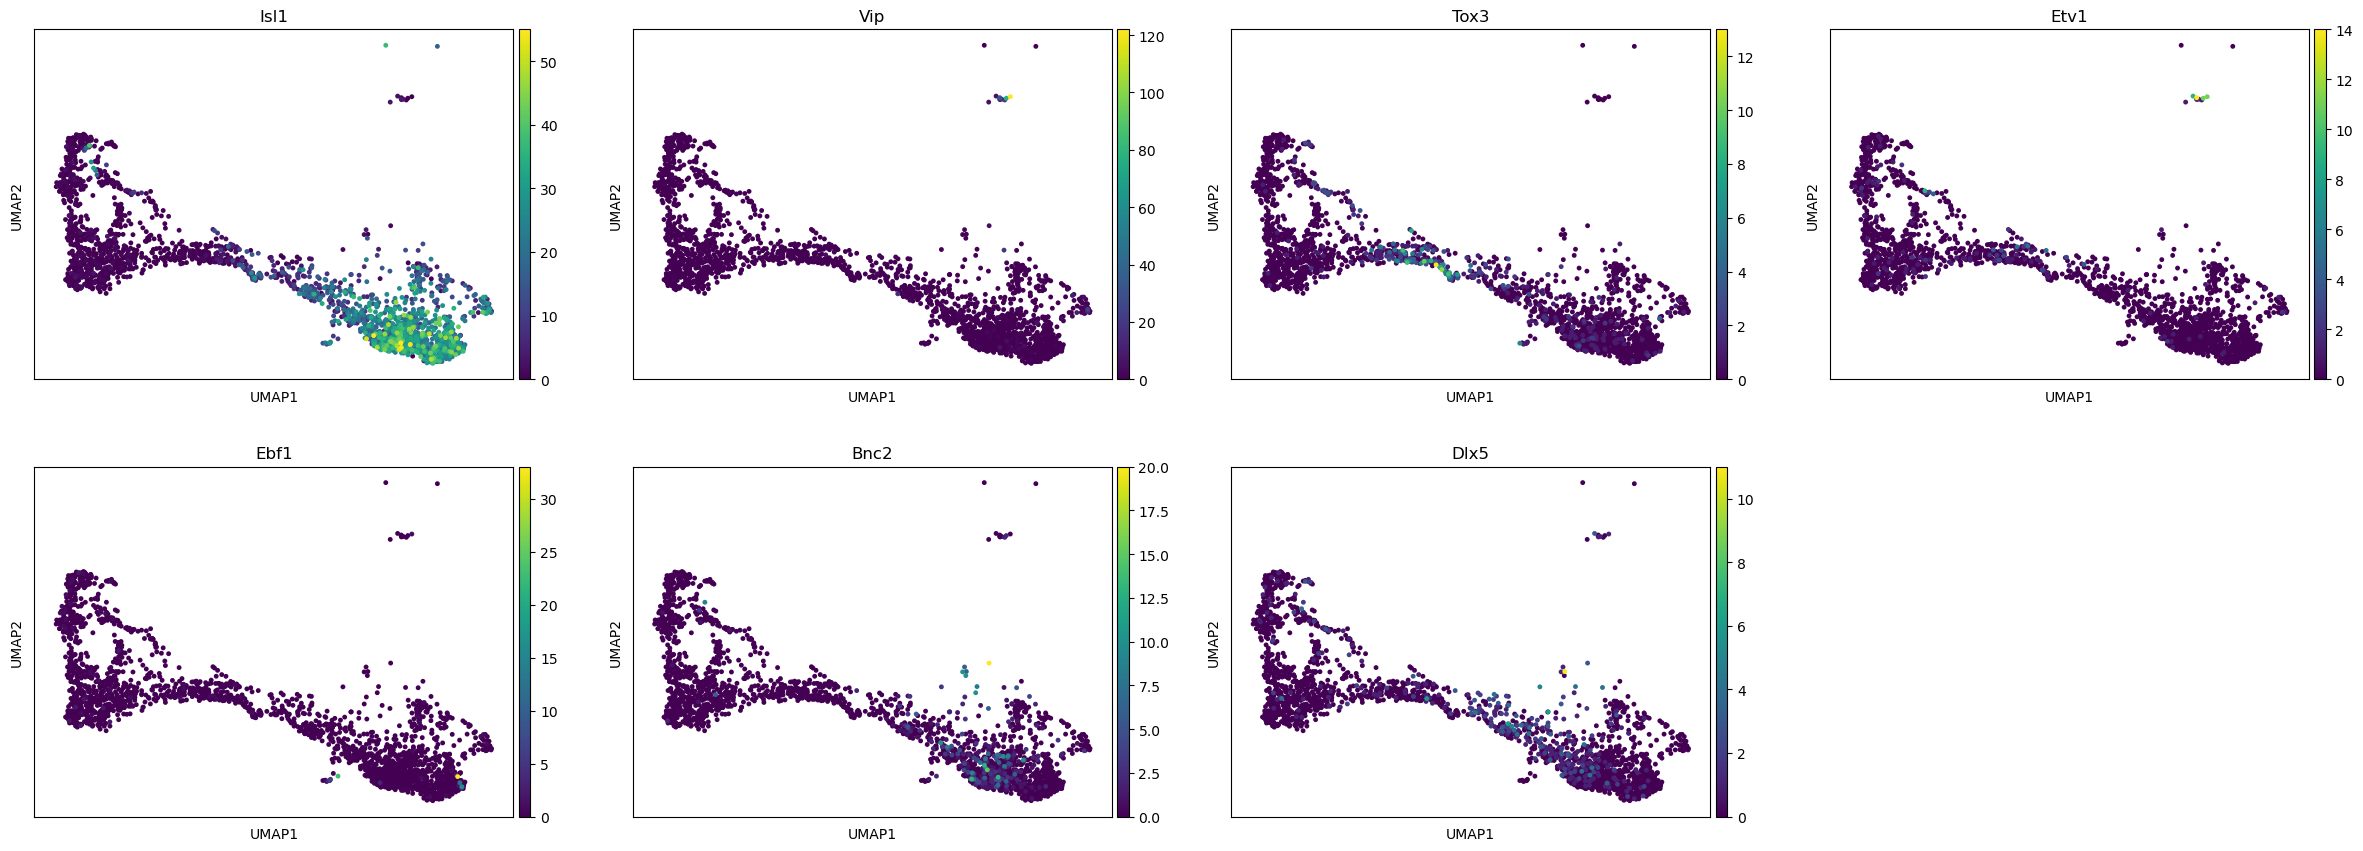

In [11]:
adata_plot_heart = adata_full[adata_full.obs["orig.ident"] == "ICN.E14.3", :]
sc.pl.umap(adata_plot_heart, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

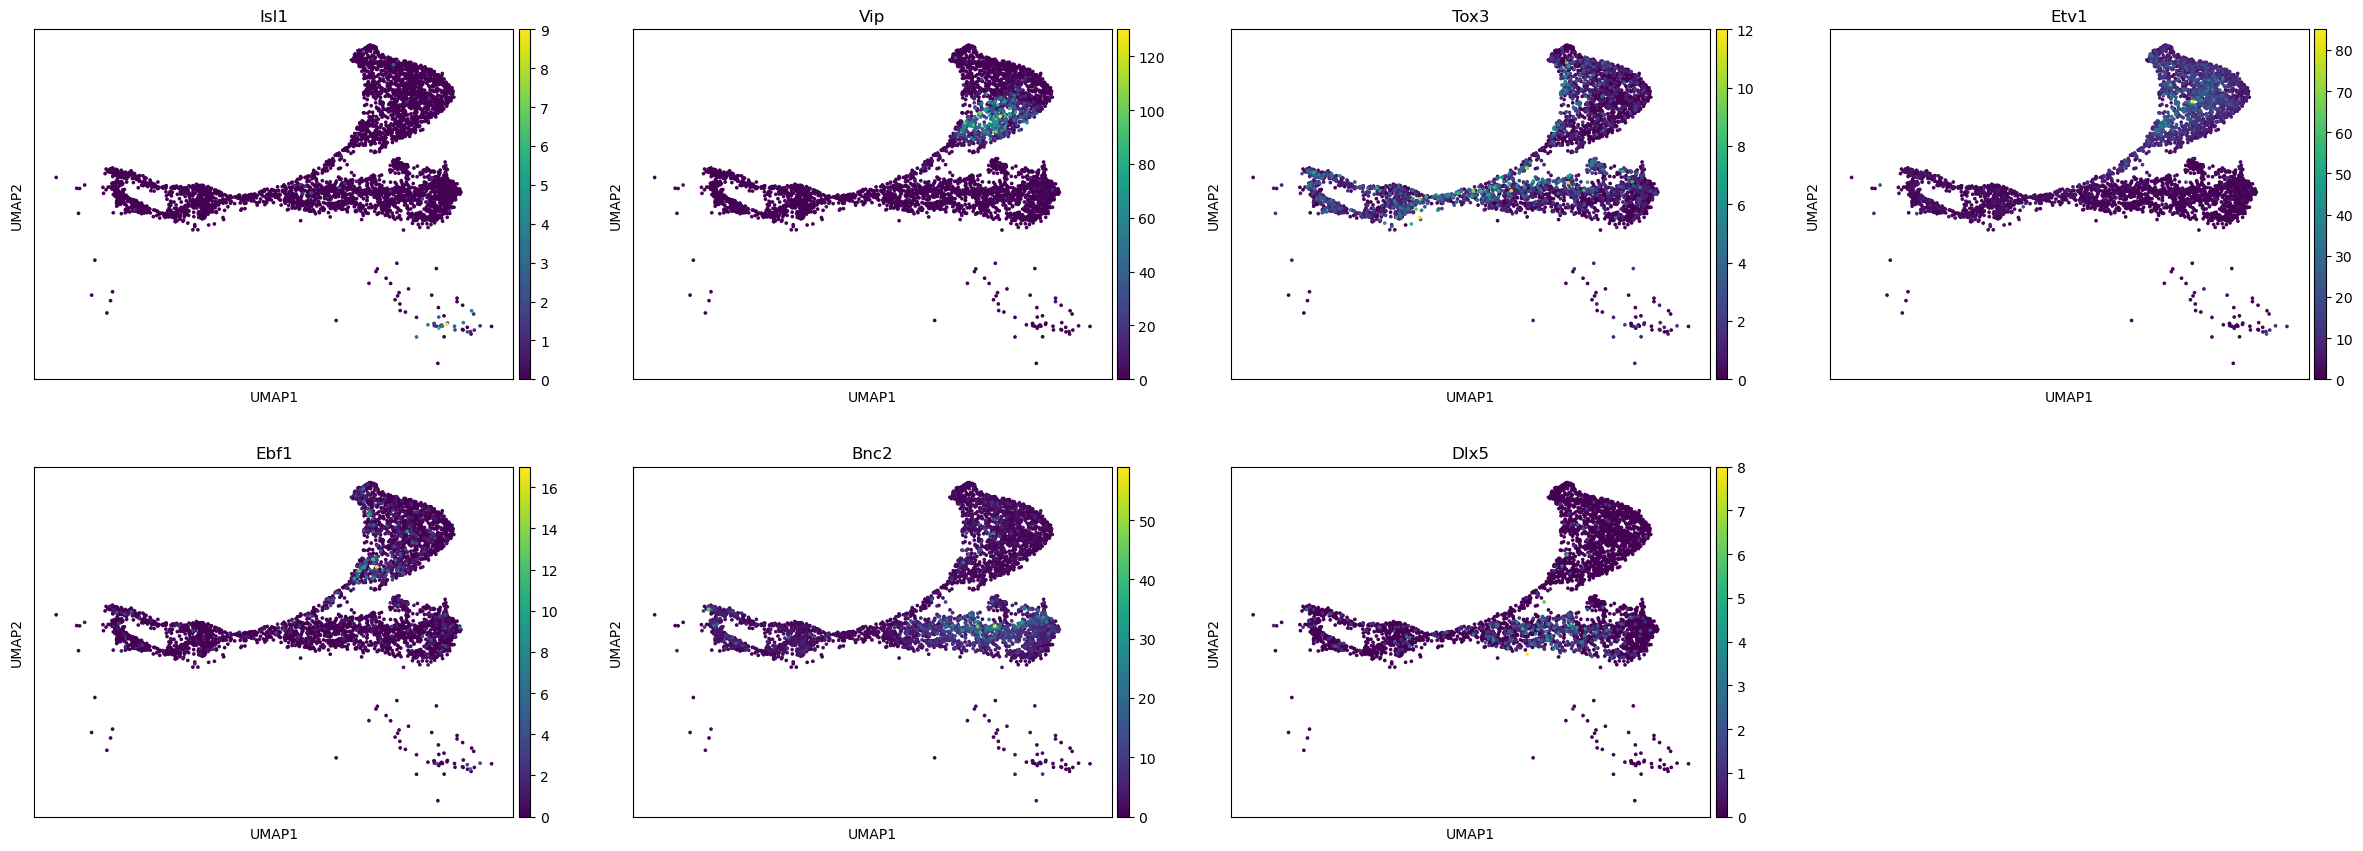

In [12]:
adata_plot_gut = adata_full[adata_full.obs["orig.ident"] == "ENS_E14", :]
sc.pl.umap(adata_plot_gut, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

In [13]:
# lowdim_list = lowdim_list[:3]

In [14]:
integrated_data = portal.utils.integrate_datasets(lowdim_list, lambda_cos=[30.0,40.0,40.0], training_steps=500, space="latent")

Incrementally integrating 4 datasets...
Integrating the 2-th dataset to the 1-st dataset...
Begining time:  Mon Mar 25 20:19:15 2024
step 0, loss_D=16.612589, loss_GAN=3.844658, loss_AE=414.470886, loss_cos=57.760998, loss_LA=311.129303
step 200, loss_D=6.147289, loss_GAN=4.933825, loss_AE=12.647842, loss_cos=5.981580, loss_LA=4.199708
step 400, loss_D=2.002351, loss_GAN=2.759818, loss_AE=6.378028, loss_cos=3.027635, loss_LA=1.726958
Ending time:  Mon Mar 25 20:19:19 2024
Training takes 4.08 seconds
Begining time:  Mon Mar 25 20:19:19 2024
Ending time:  Mon Mar 25 20:19:19 2024
Evaluating takes 0.04 seconds
Integrating the 3-th dataset to the 1-st dataset...
Begining time:  Mon Mar 25 20:19:19 2024
step 0, loss_D=17.070005, loss_GAN=3.340371, loss_AE=385.164001, loss_cos=78.253983, loss_LA=280.327393
step 200, loss_D=4.501984, loss_GAN=4.186789, loss_AE=10.927758, loss_cos=7.874192, loss_LA=4.121760
step 400, loss_D=1.777473, loss_GAN=3.202105, loss_AE=5.516207, loss_cos=3.870817, loss

/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/jz874/.conda/envs/mc_portal_env_torch1/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(local_connectivity=1, min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Mon Mar 25 20:19:27 2024 Construct fuzzy simplicial set
Mon Mar 25 20:19:27 2024 Finding Nearest Neighbors
Mon Mar 25 20:19:27 2024 Building RP forest with 10 trees
Mon Mar 25 20:19:27 2024 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon Mar 25 20:19:32 2024 Finished Nearest Neighbor Search
Mon Mar 25 20:19:32 2024 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Mar 25 20:19:43 2024 Finished embedding


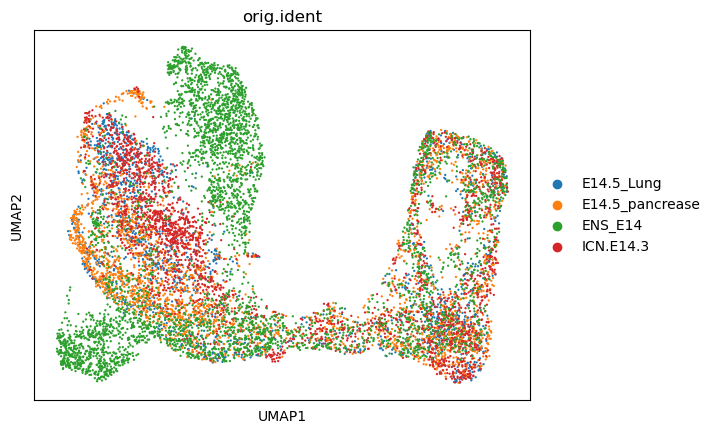

In [15]:
adata_plot = adata_lung.concatenate(adata_pan, adata_heart, adata_gut)

import umap
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="euclidean",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(integrated_data)
adata_plot.obsm["X_umap"] = embedding

# adata_plot.obsm["integrated"] = integrated_data
# sc.pp.neighbors(adata_plot, use_rep="integrated", n_neighbors=20)
# sc.tl.umap(adata_plot)

sc.pl.umap(adata_plot, color=["orig.ident"])

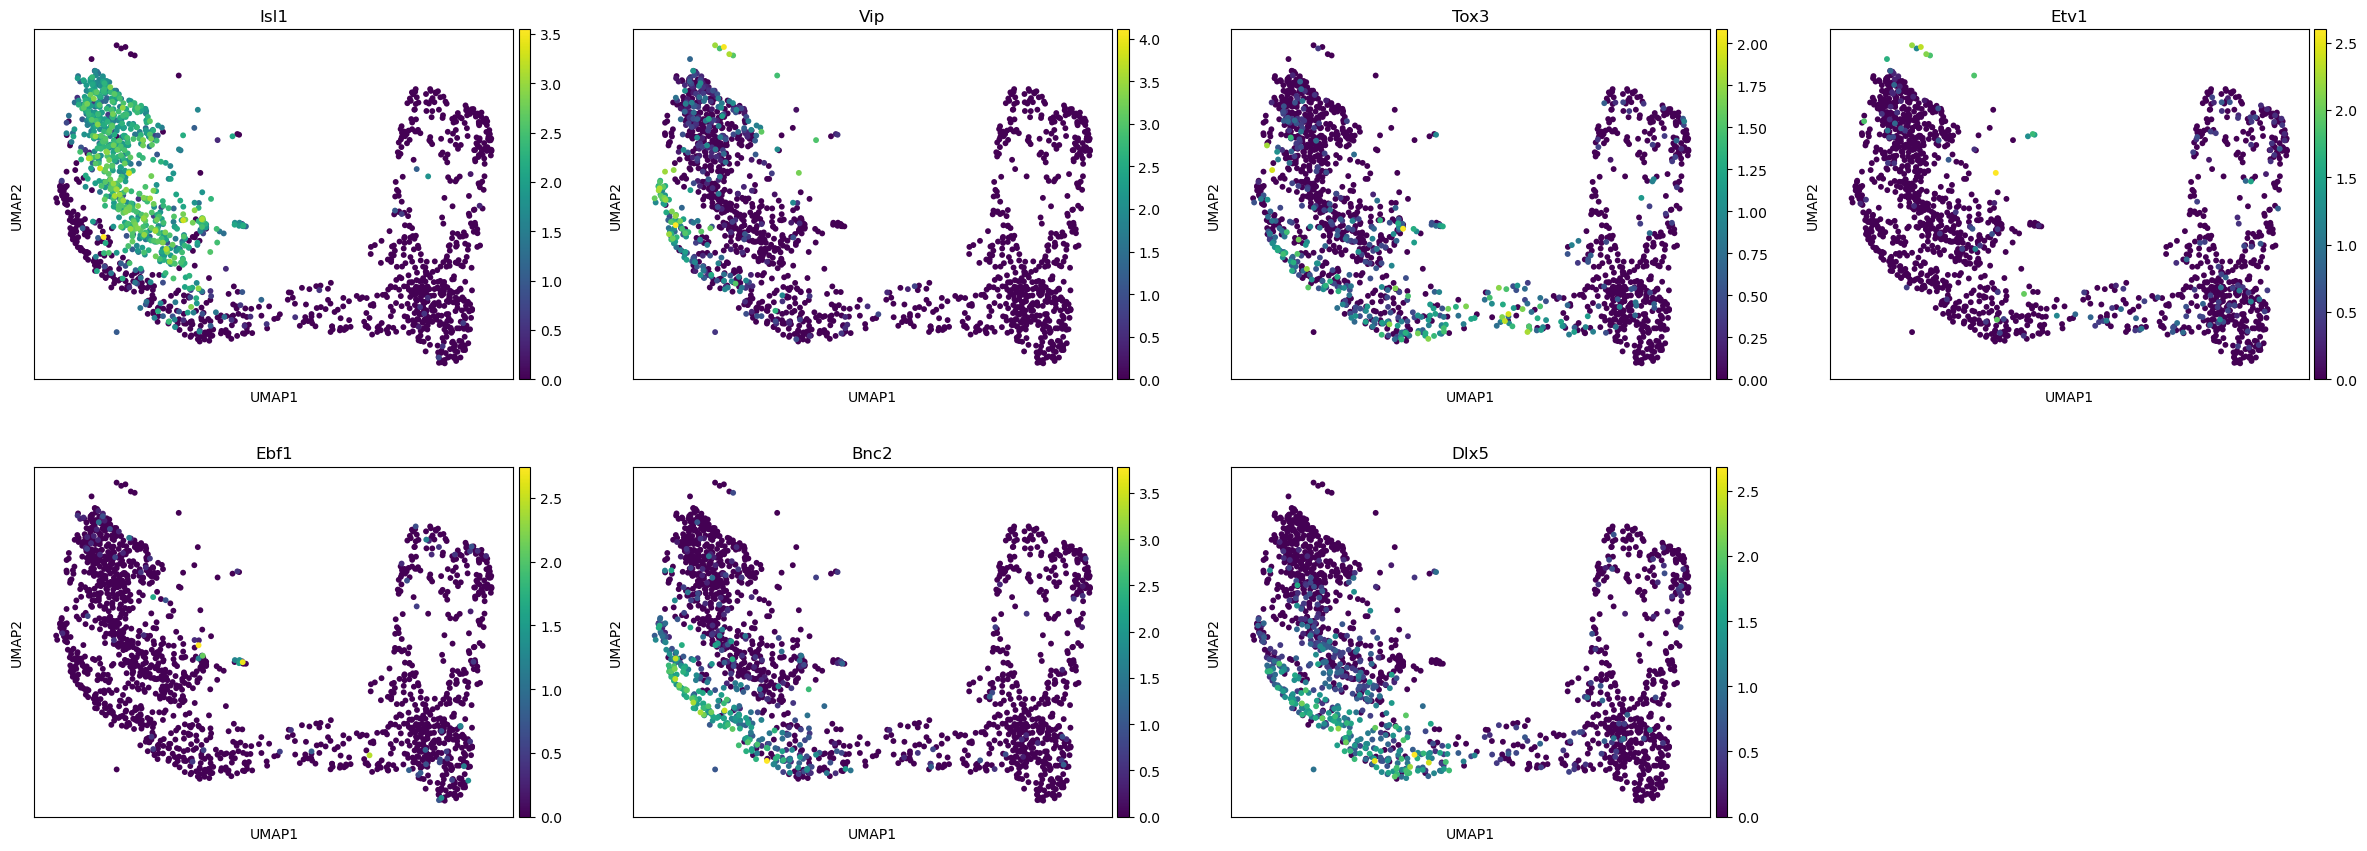

In [16]:
adata_lung = adata_plot[adata_plot.obs["orig.ident"] == "E14.5_Lung", :]
sc.pl.umap(adata_lung, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

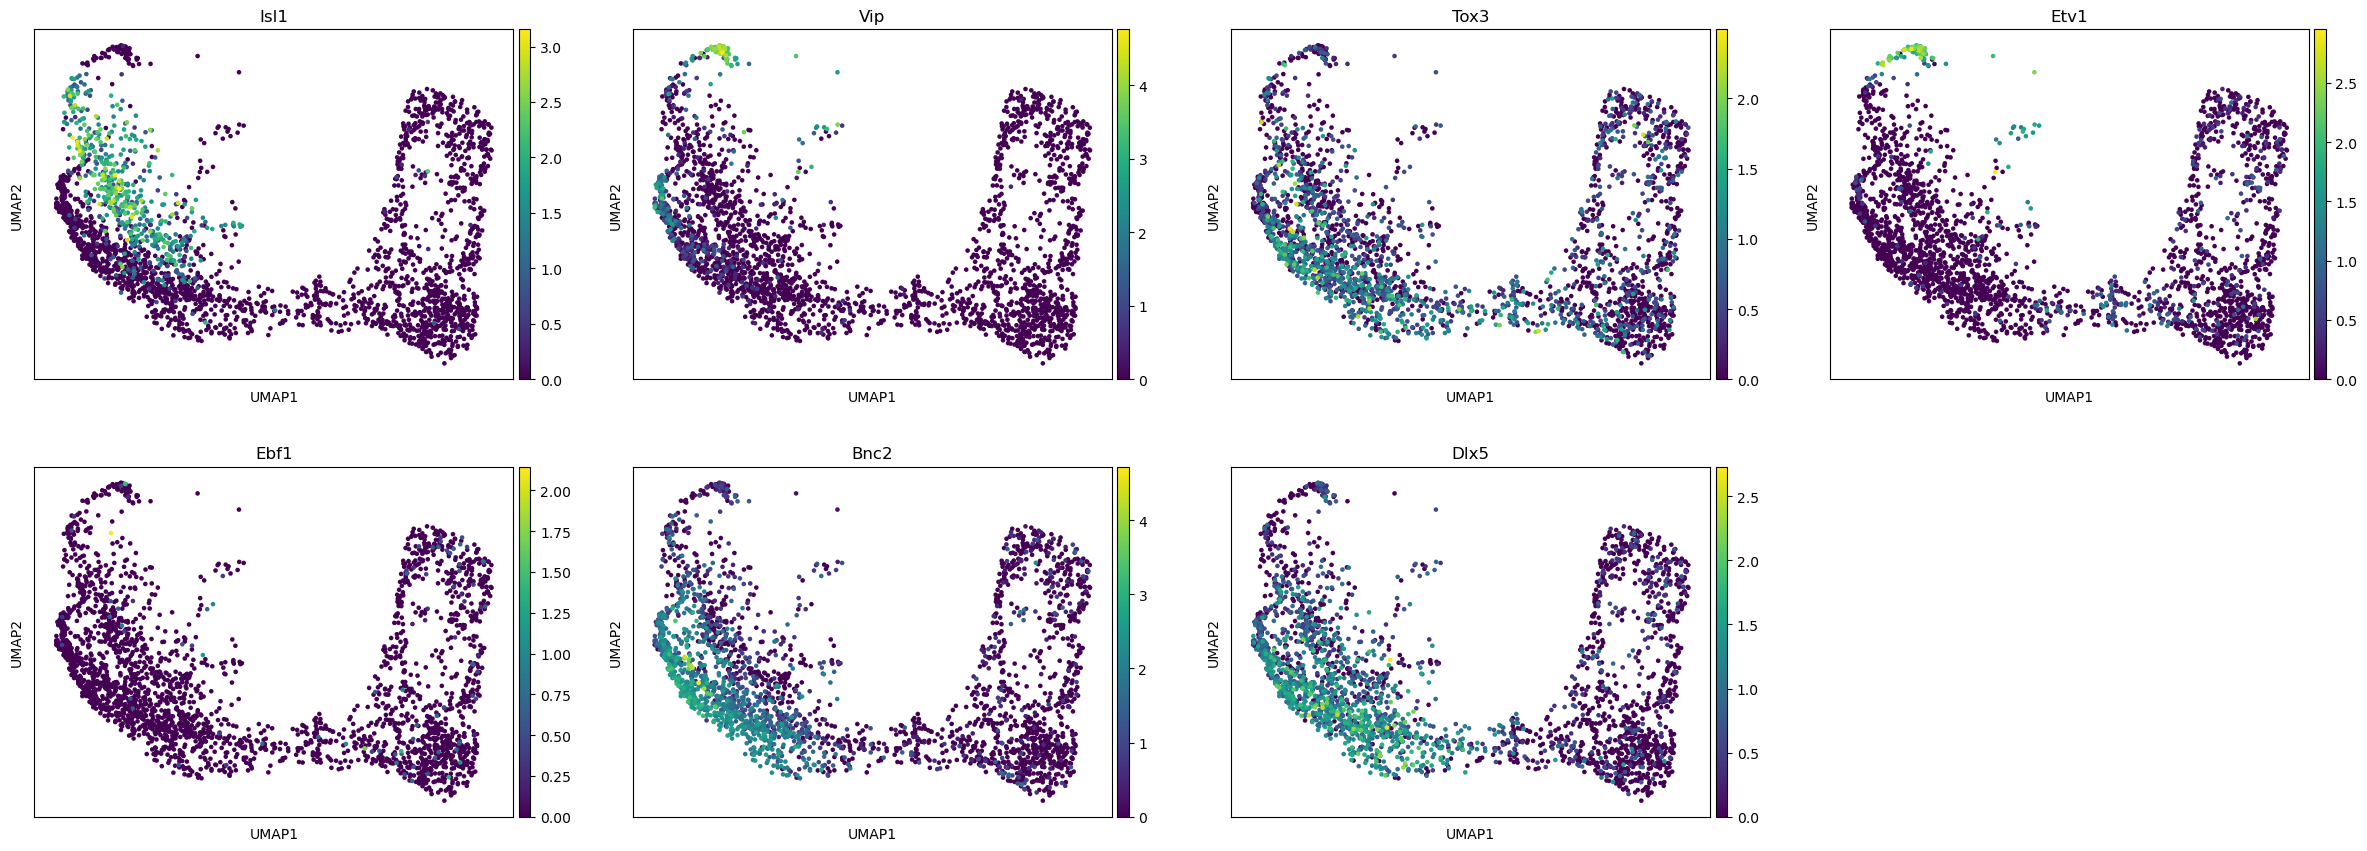

In [17]:
adata_pan = adata_plot[adata_plot.obs["orig.ident"] == "E14.5_pancrease", :]
sc.pl.umap(adata_pan, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

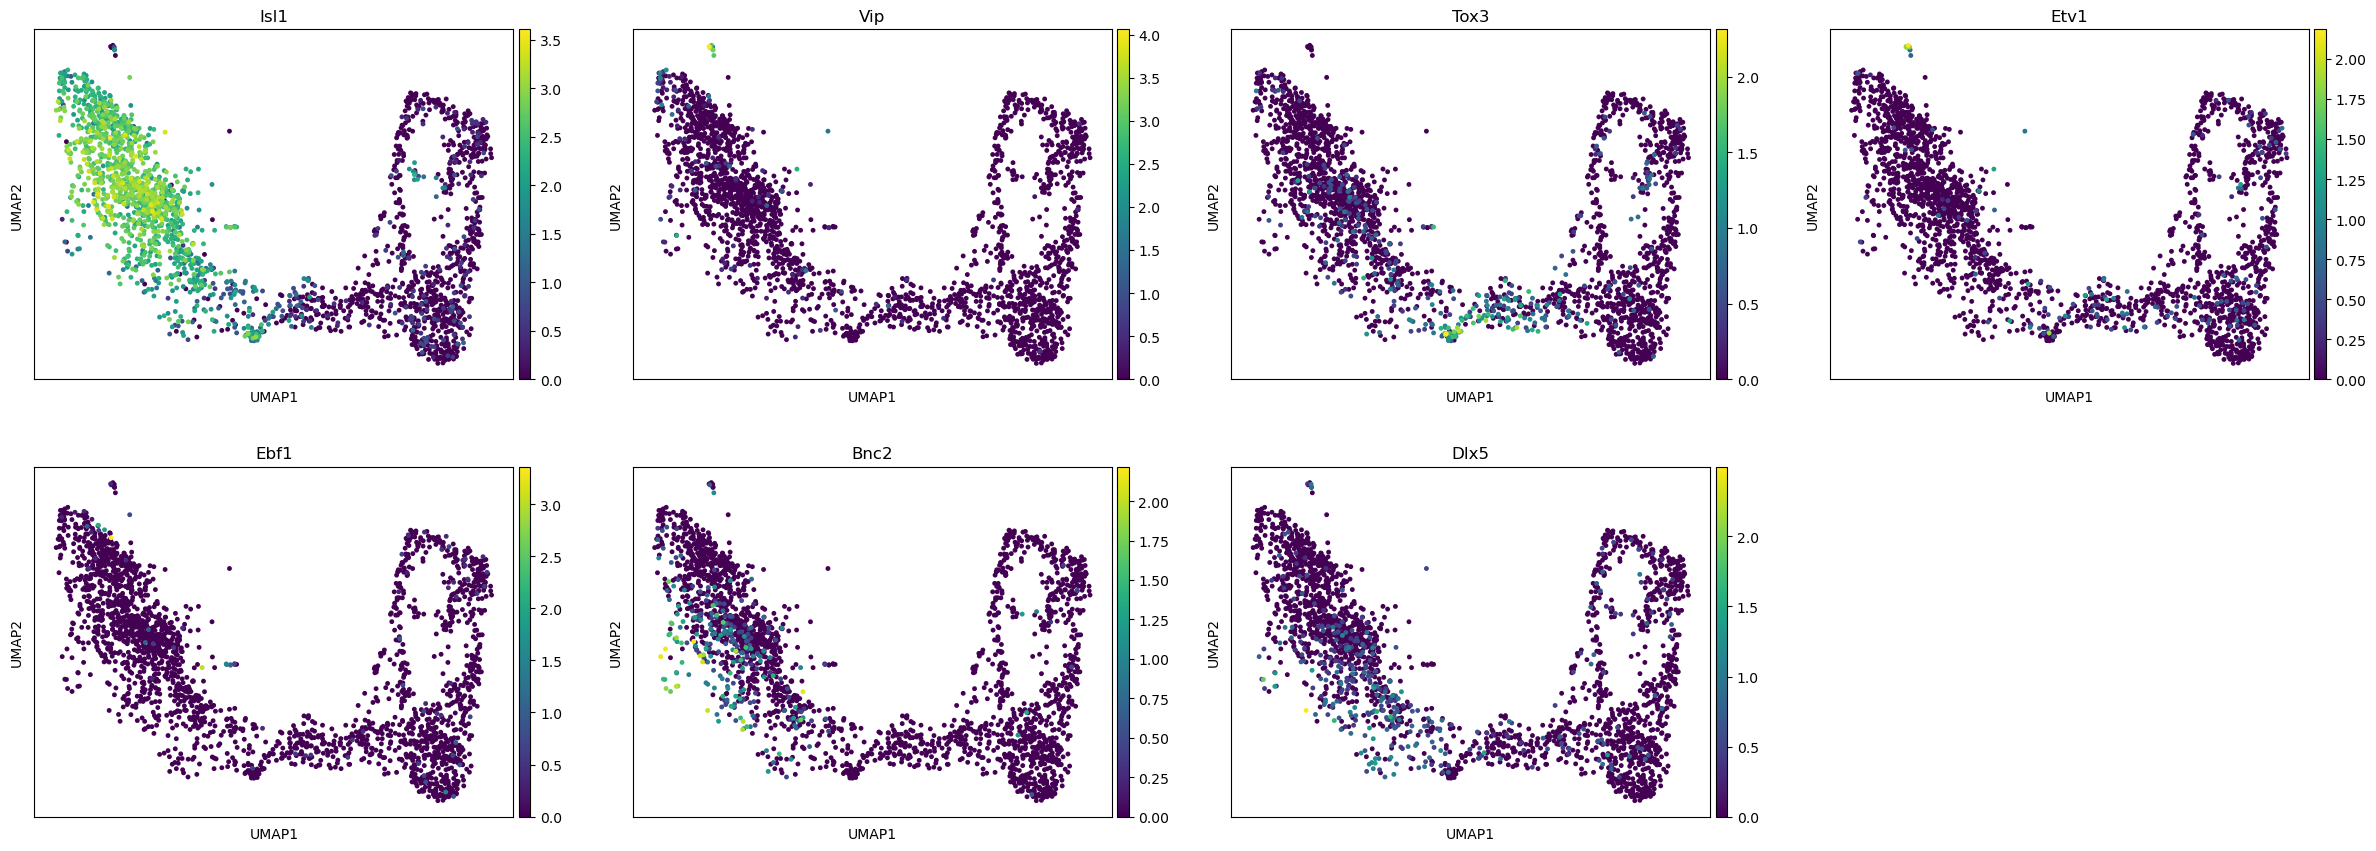

In [18]:
adata_heart = adata_plot[adata_plot.obs["orig.ident"] == "ICN.E14.3", :]
sc.pl.umap(adata_heart, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

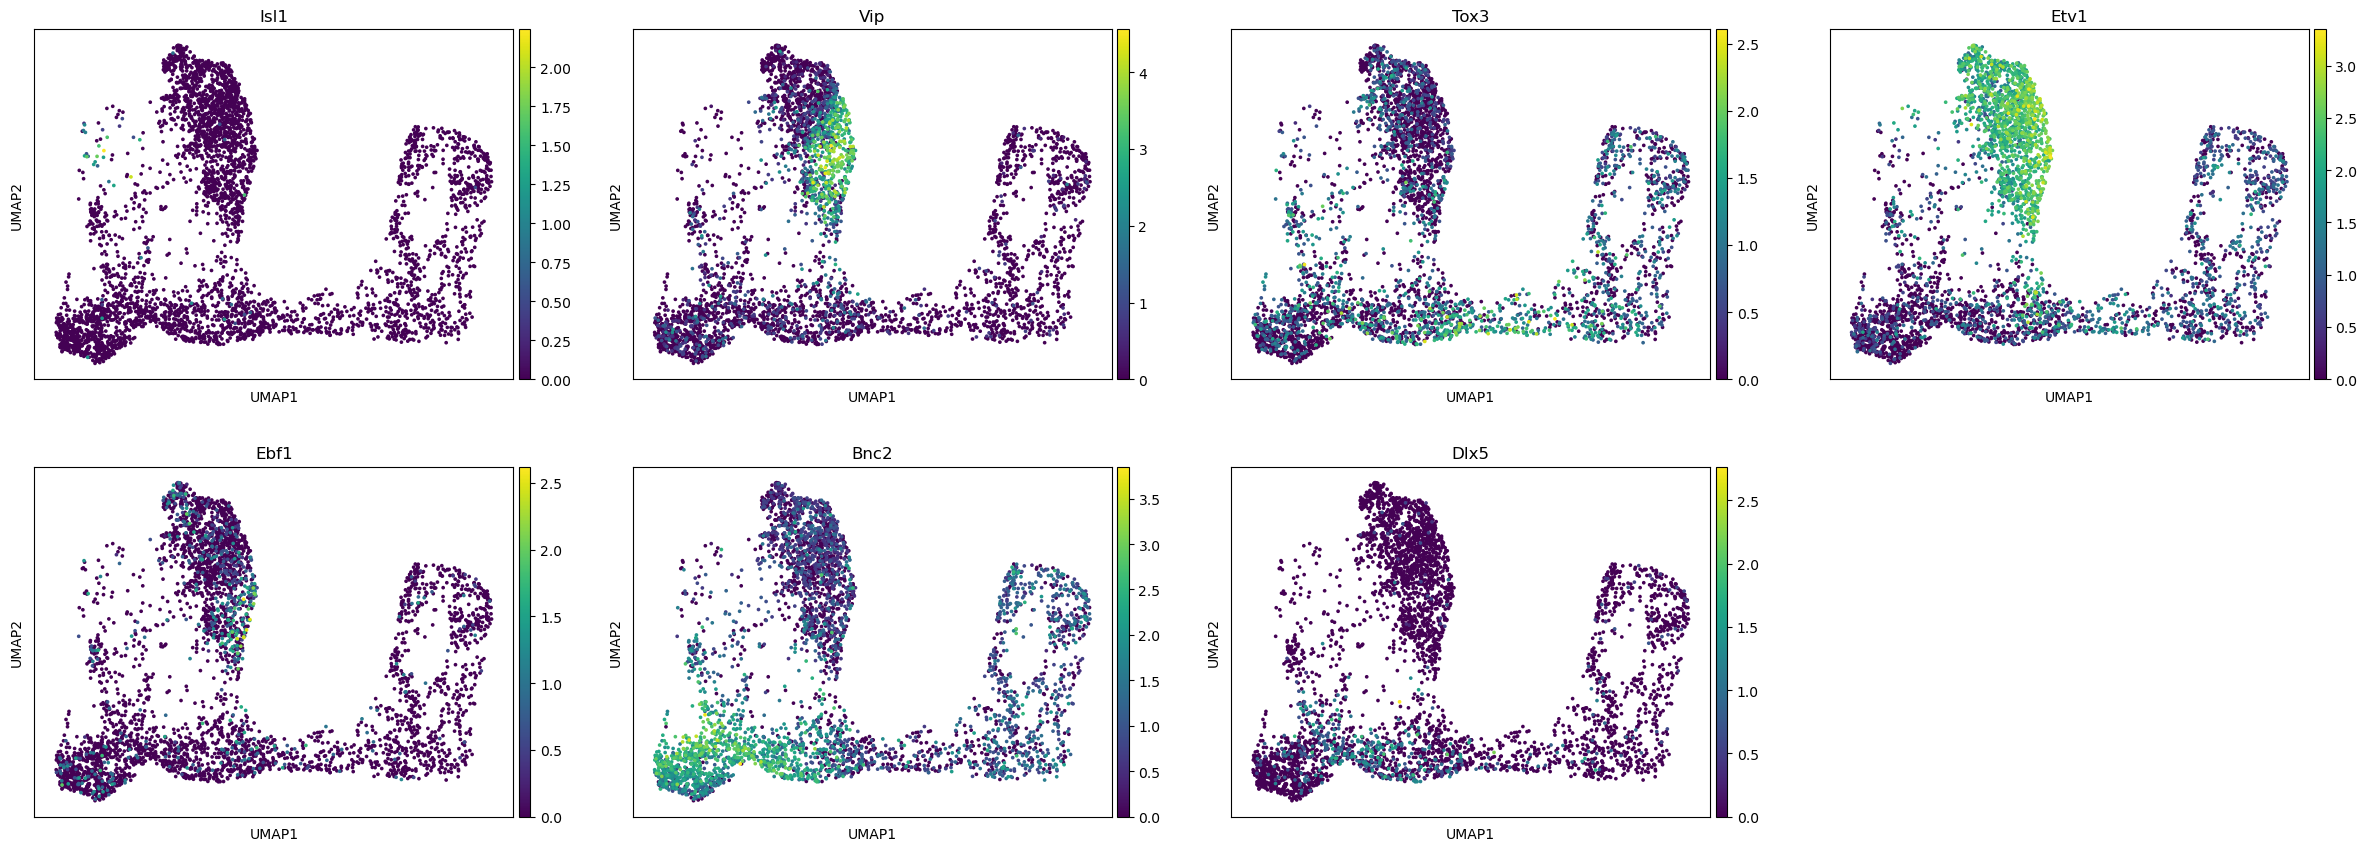

In [19]:
adata_gut = adata_plot[adata_plot.obs["orig.ident"] == "ENS_E14", :]
sc.pl.umap(adata_gut, color=["Isl1","Vip","Tox3","Etv1","Ebf1","Bnc2","Dlx5"], use_raw=False)

In [20]:
res_path = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/oin_trajectory_integration_portal/results"
adata_plot.write(res_path + "/Mar25_portal_4organOIN_withoutNPC_v1.h5ad")